In [1]:
%pip install --quiet rawpy exifread requests tqdm opencv-python matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 66.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 4.6 MB/s eta 0:00:00


In [118]:
%pip install pympler

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.8/165.8 kB 10.7 MB/s eta 0:00:00


## Imports

In [29]:
import json
import random
from pathlib import Path
import rawpy
import exifread
import cv2
import numpy as np
import requests
from tqdm.auto import tqdm
import tifffile, collections
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

## GLOBAL PARAMS

In [109]:
DATA_DIR = Path("fivek_data")            # realtiv to notebook
DNG_DIR = DATA_DIR / "dng"
OUT_DIR = DATA_DIR / "simulated"
for d in (DNG_DIR, OUT_DIR):
    d.mkdir(parents=True, exist_ok=True)

N_OUTDOOR = 1000        # nb of outdoor to get
N_INDOOR = 740         # nb of DNG "indoor"
N_EXAMPLES = 500       # nb of examples to simulate (m, t, r, c) 
JPEG_QUALITY = 95      # jpeg quality
SAVE_LINEAR = False    # True to save .npz sRGB linear
PATCH = 512            # 256p like in the paper
TAU = 0.1329           # exposition objectif of the mean pixel (Func. S1)
MAX_SIDE = 1000        #  max size of RAW kept in memory
SEED = 1009
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
rng = np.random.default_rng(SEED)
rnd = random.Random(SEED)


## UTILS

In [31]:
DNG = {"ColorMatrix1": 0xC621, "ColorMatrix2": 0xC622,
       "CameraCalibration1": 0xC623, "CameraCalibration2": 0xC624,
       "AnalogBalance": 0xC627, "AsShotNeutral": 0xC628, "AsShotWhiteXY": 0xC629,
       "CalibrationIlluminant1": 0xC65A, "CalibrationIlluminant2": 0xC65B}


NOMS = {0xC621:"ColorMatrix1", 0xC622:"ColorMatrix2", 0xC623:"CameraCalibration1",
    0xC624:"CameraCalibration2", 0xC627:"AnalogBalance", 0xC628:"AsShotNeutral",
    0xC629:"AsShotWhiteXY", 0xC65A:"CalibrationIlluminant1",
    0xC65B:"CalibrationIlluminant2", 0xC65C:"BestQualityScale"}

_FLIP = {
    0: lambda a: a,                     # no rotation
    3: lambda a: a[::-1, ::-1],         # 180°
    5: lambda a: np.rot90(a, 1),        # 90° anticlockwise
    6: lambda a: np.rot90(a, -1),       # 90° clockwise
}


def dng_tag(tags, name):
    """Lit un tag DNG. exifread ne les nomme pas : on passe par l'ID hexa."""
    t = tags.get("Image Tag 0x%04X" % DNG[name])
    if t is None:
        return None
    out = []
    for v in t.values:
        out.append(float(v.num) / float(v.den) if hasattr(v, "num") else float(v))
    return np.array(out, np.float64)

def reject_noms(dng_file):
        with open(dng_file[0], "rb") as f:
            tags = exifread.process_file(f, details=False)
        asshot = dng_tag(tags,"AsShotNeutral")
        whitexy = dng_tag(tags, "AsShotWhiteXY")
        if asshot is None and whitexy is None:
            return False
        return True
            

## DOWNLOADING DATA (NOTEBOOK)

In [110]:
META_URL = "https://huggingface.co/datasets/yuukicammy/MIT-Adobe-FiveK/raw/main/training.json"

meta_path = DATA_DIR / "training.json"
if not meta_path.exists():
    resp = requests.get(META_URL, timeout=120)
    resp.raise_for_status()
    meta_path.write_bytes(resp.content)
metadata = json.loads(meta_path.read_text())
print(f"{len(metadata)} images référencées")

by_loc = {}
for name, item in metadata.items():
    loc = item.get("categories", {}).get("location", "unknown")
    by_loc.setdefault(loc, []).append((name, item))
print({k: len(v) for k, v in sorted(by_loc.items())})

selection = []
for loc, n in [("outdoor", N_OUTDOOR), ("indoor", N_INDOOR)]:
    items = list(by_loc.get(loc, []))
    rnd.shuffle(items)
    selection += [(name, item, loc) for name, item in items[:n]]


def download_dng(name, item):
    url = item["urls"]["dng"].replace("http://", "https://")
    path = DNG_DIR / f"{name}.dng"
    if path.exists() and path.stat().st_size > 0:
        return path
    with requests.get(url, stream=True, timeout=300) as resp:
        resp.raise_for_status()
        tmp = path.with_suffix(".part")
        with open(tmp, "wb") as f:
            for chunk in resp.iter_content(1 << 20):
                f.write(chunk)
        tmp.rename(path)
    return path


dng_files = []  
for name, item, loc in tqdm(selection, desc="DNG"):
    try:
        dng_file = ((download_dng(name, item), loc,
                          item.get("categories", {})))
        # making sure to get images with the right metadata
        bool = reject_noms(dng_file)
        if bool:
            dng_files.append(dng_file)
    except Exception as exc:
        print(f"échec {name}: {exc}")

total_mb = sum(p.stat().st_size for p, _, _ in dng_files) / 1e6
print(f"{len(dng_files)} DNG prêts ({total_mb:.0f} Mo)")


3500 images référencées
{'indoor': 748, 'outdoor': 2513, 'unknown': 239}


DNG:   0%|          | 0/1740 [00:00<?, ?it/s]

1723 DNG prêts (16807 Mo)


## TESTS 

Big difference between Rawpy and adobe SNK processing is with opcodes that we don't find in our dataset, so both methods are similar here.

In [33]:
import tifffile, collections

OPCODES = {51008: "OpcodeList1", 51009: "OpcodeList2", 51022: "OpcodeList3"}
hits = collections.Counter()
for p, *_ in dng_files[:50]:
    with tifffile.TiffFile(str(p)) as tif:
        for page in list(tif.pages) + [sub for pg in tif.pages for sub in (pg.pages or [])]:
            for code, name in OPCODES.items():
                if code in page.tags:
                    hits[name] += 1
print(hits or "aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset")

aucun opcode -> LibRaw ≈ ACR étapes 1-4 sur ce dataset


Tester si y'a -1 comme size.flip dans le dataset

In [34]:

c = collections.Counter()
for p, *_ in dng_files:
    with rawpy.imread(str(p)) as raw:
        c[raw.sizes.flip] += 1
print(c)

Counter({0: 311, 5: 105, 6: 78, 1: 1, 3: 1})


## Calculating WhiteXY, Interpolation of ColorMatrix1/2, xy space and XYZ space

<strong style="color: green;">CLEARED</strong>, I'm sure about this one

In [35]:


# temperatures of the normalized illuminants (EXIF LightSource, spec DNG ch. 6)
ILLUMINANT_TEMP = {1: 6504., 2: 4100., 3: 2856., 4: 5500., 9: 5500., 10: 6504.,
                   11: 7504., 12: 6430., 13: 5050., 14: 4150., 15: 3450.,
                   17: 2856., 18: 4874., 19: 6774., 20: 5503., 21: 6504.,
                   22: 7504., 23: 5003., 24: 3200.}
# ------------------------------------------------------- xy -> temperature
def xy_to_temp(xy):
    """CCT par l'approximation de McCamy (1992). L'ecart a la methode de
    Robertson de la spec DNG est de quelques kelvins pres du lieu planckien."""
    x, y = float(xy[0]), float(xy[1])
    n = (x - 0.3320) / (0.1858 - y + 1e-12)
    return 449.0 * n ** 3 + 3525.0 * n ** 2 + 6823.3 * n + 5520.33


# ------------------------------------------- Func. S7 : XYZ -> camera pour un xy
def find_xyz_to_camera(xy, cal):
    """Interpole entre les deux matrices de calibration selon la temperature
    du point blanc vise. L'interpolation se fait en 1/T (mireds), pas en T."""
    t1, t2 = cal["temp1"], cal["temp2"]
    cm1, cm2 = cal["cm1"], cal["cm2"]
    cc1, cc2 = cal["cc1"], cal["cc2"]
    if cm2 is None:                                  # une seule calibration
        cm, cc = cm1, cc1
    else:
        temp = xy_to_temp(xy)
        if temp <= min(t1, t2):
            g = 1.0 if t1 <= t2 else 0.0
        elif temp >= max(t1, t2):
            g = 0.0 if t1 <= t2 else 1.0
        else:
            g = (1.0 / temp - 1.0 / t2) / (1.0 / t1 - 1.0 / t2)
        cm = g * cm1 + (1.0 - g) * cm2
        cc = g * cc1 + (1.0 - g) * cc2
    return cal["ab"] @ cc @ cm                       # AB . CC . CM


# ------------------------------- Func. S3 : AsShotNeutral -> xy (point fixe)
def neutral_to_xy(neutral, cal, n_iter=30, tol=1e-9):
    """La matrice depend du point blanc, qui depend de la matrice : on itere.
    Depart a D50, comme la spec DNG."""
    xy = np.array([0.34567, 0.35850])                # D50
    for _ in range(n_iter):
        xyz = np.linalg.solve(find_xyz_to_camera(xy, cal), neutral)
        new = np.array([xyz[0], xyz[1]]) / max(xyz.sum(), 1e-12)
        if np.abs(new - xy).max() < tol:
            return new, True
        xy = new
    return xy, False

def read_calibration(path):
    """getting what Func. S7. needs"""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)
    ashot = dng_tag(tags, "AsShotNeutral")
    cm1 = dng_tag(tags, "ColorMatrix1")
    cm2 = dng_tag(tags, "ColorMatrix2")
    cc1 = dng_tag(tags, "CameraCalibration1")
    cc2 = dng_tag(tags, "CameraCalibration2")
    il1 = dng_tag(tags, "CalibrationIlluminant1")
    il2 = dng_tag(tags, "CalibrationIlluminant2")
    ab = dng_tag(tags, "AnalogBalance")
    eye = np.eye(3)
    cal = {"cm1": cm1.reshape(3, 3),
           "cm2": None if cm2 is None else cm2.reshape(3, 3),
           "cc1": eye if cc1 is None else cc1.reshape(3, 3),
           "cc2": eye if cc2 is None else cc2.reshape(3, 3),
           "ab": eye if ab is None else np.diag(ab),
           "temp1": ILLUMINANT_TEMP.get(int(il1[0]) if il1 is not None else 17, 2856.),
           "temp2": ILLUMINANT_TEMP.get(int(il2[0]) if il2 is not None else 21, 6504.), "ashot": ashot}
    return cal, tags

# ------------------------------------------------------------- Func. S3
def compute_white_xy(path):
    """WhitePoint in xy. Use AsShotWhiteXY if it exists, uses otherwise
    AsShotNeutral.Both are present in our current filtered DATASET."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")

    if xy is not None:
        return np.asarray(xy[:2], np.float64), "AsShotWhiteXY", True

    neutral = dng_tag(tags, "AsShotNeutral")
    # if neutral is None:
    #     raise ValueError("ni AsShotWhiteXY ni AsShotNeutral dans %s" % path)
    
    xy, ok = neutral_to_xy(neutral[:3], cal)
    return xy, "AsShotNeutral", ok

def xy_to_xyz(xy, Y=1.0):
    """Chromaticity -> tristimulus, Luminance = Y = 1."""
    x, y = float(xy[0]), float(xy[1])
    return np.array([Y * x / y, Y, Y * (1.0 - x - y) / y])

def camera_to_xyz(path):
    """Matrice CAM -> XYZ (Func. S3 l.5-7) and WhitePoint as-shot."""
    cal, tags = read_calibration(path)
    xy = dng_tag(tags, "AsShotWhiteXY")
    if xy is not None:
        xy, ok = np.asarray(xy[:2], np.float64), True
    else:
        neutral = dng_tag(tags, "AsShotNeutral")
        # if neutral is None:
        #     raise ValueError(f"ni AsShotWhiteXY ni AsShotNeutral dans {path}")
        xy, ok = neutral_to_xy(neutral[:3], cal)
        if not ok:
            print(f"NeutralToXY n'a pas convergé: {path}")
    return np.linalg.inv(find_xyz_to_camera(xy, cal)).astype(np.float32), xy

# XYZ -> CAM :  M = find_xyz_to_camera(xy, cal)
# CAM -> XYZ:   inv(M)

## RAW IMAGE PROCESSING

<strong style="color: RED;"> NOT CLEARED</strong>

In [36]:
def clip_level(raw, min_pixels=64):
    """Plus bas des deux plafonds : le plateau réel du capteur, et le white_level
    au-dessus duquel LibRaw aplatit tout dans postprocess. Pas de plateau
    détecté -> pas d'écrêtage capteur -> seul le plafond LibRaw compte."""
    wl  = float(raw.white_level)
    vis = raw.raw_image_visible
    mx  = int(vis.max())
    if int((vis >= mx - 1).sum()) >= min_pixels:
        return min(wl, float(mx))
    return wl


read_raw_to_xyz is complicated and I need to find what to do with my white level, where my saturation mask acts

In [45]:
def read_exposure(path):
    """Exposition e = s * g / n**2 (Sec. 3.1 du papier)."""
    with open(path, "rb") as f:
        tags = exifread.process_file(f, details=False)

    def tag(name, default):
        t = tags.get(name)
        if t is None or not t.values:
            print(f"Il manque la valeur {name}")
            return default, False
        v = t.values[0]
        try:
            return float(v.num) / float(v.den), True
        except AttributeError:
            return float(v), True

    s, bool_s = tag("EXIF ExposureTime", 1 / 60)         
    n, bool_n = tag("EXIF FNumber", 4.0)         
    g, bool_g = tag("EXIF ISOSpeedRatings", 100.0)       
    return s * g / max(n, 0.7) ** 2, bool_s * bool_n * bool_g

_PP = dict(gamma=(1, 1), no_auto_bright=True, adjust_maximum_thr=0, output_bps=16,
           use_camera_wb=False, use_auto_wb=False, user_wb=[1.0, 1.0, 1.0, 1.0],
           output_color=rawpy.ColorSpace.raw)


def align_mask(path, sat_b, **pp):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2])."""
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = 0
        v[sat_b] = int(raw.white_level)
        out = raw.postprocess(**pp)
        print(out.shape, out.max(-1).shape, out.max())
    return np.ascontiguousarray(out.max(-1) > 0.25 * 65535)

def align_maskv2(mask, shape, flip=0, path=None, half_size=True):
    """mask : bool HxW en repère capteur -> repère `shape` (= cam.shape[:2]).
       optimized version
    """
    h, w = mask.shape
    if (h, w) == tuple(shape):            # DNG linéaire : pas de binning côté LibRaw
        return np.ascontiguousarray(mask)

    m = np.pad(mask, ((0, h % 2), (0, w % 2)))          # ceil, comme LibRaw
    m = m.reshape(-1, 2, m.shape[1] // 2, 2).any(axis=(1, 3))
    m = _FLIP.get(flip, lambda a: a)(m)
    if m.shape == tuple(shape):
        return np.ascontiguousarray(m)
    # géométrie non affine (fuji_rotate, pixel_aspect...) : on refait passer
    # le masque dans le MEME postprocess que l'image.
    with rawpy.imread(str(path)) as raw:
        v = raw.raw_image_visible
        v[:] = np.where(mask, int(raw.white_level),0)
        out = raw.postprocess(half_size=half_size, **_PP)
    return np.ascontiguousarray(out.max(-1) > 0) #really conservative, dilating the mask a bit

def read_raw_to_xyz(path, half_size=True):
    """ACR étapes 1-4 : linearization, dématriçage, black level, -> XYZ.

    user_wb=(1,1,1,1) no white balance, we get XYZ
    "as-shot" where illuminants color is preserved.
    
    Output (xyz, illuminant_xyz, saturated, sat_bool)

    sat_bool = False for sRAW images where the bayer mask to get saturation mask makes no sense
    """
    with rawpy.imread(str(path)) as raw:
        black = np.mean(raw.black_level_per_channel)
        wl    = raw.white_level #clip_level(raw, min_pixels=64) # 
        bayer = raw.raw_image_visible
        sat_b = bayer >= black + 0.98 * (wl - black)
        if sat_b.ndim == 3:              # sRAW / DNG linear : no mosaic, I have to take them off later
            return None, None, None, False
        
        cam = raw.postprocess(
            gamma=(1, 1),
            no_auto_bright=True,
            adjust_maximum_thr=0,
            output_bps=16,
            use_camera_wb=False, 
            use_auto_wb=False, 
            user_wb=[1.0, 1.0, 1.0, 1.0],
            output_color=rawpy.ColorSpace.raw,  
            half_size=half_size,)
        saturated = align_maskv2(sat_b, cam.shape[:2], raw.sizes.flip, path)

        # ColorMatrix of DNG : XYZ -> CAM (rgb camera) ; we inverse it (step 4 ACR)
        cam_to_xyz, xy = camera_to_xyz(path)

    illum = None
    white_xyz = xy_to_xyz(xy)
    illum = white_xyz

    # output_bps=16 gives uint16: (2^16 - 1 = 65535),
    # we normalize ([0,1])/ Saturation >= 1. 
    cam = cam.astype(np.float32) / 65535.0

    # func S6.
    cam_white = np.linalg.solve(cam_to_xyz, illum)   # = inv(cam_to_xyz) @ illum
    cam_white = np.clip(cam_white / cam_white.max(), 0.001, 1.0).astype(np.float32)
    cam = np.minimum(cam, cam_white) 
    
    xyz = np.einsum("ij,hwj->hwi", cam_to_xyz, cam)
    return np.clip(xyz, 0, None), illum, saturated, True


I tested what happens to the saturation mask after resizing especially in <strong>load_pool</strong> and the maks is almost the same.
You can see the comparison in <p style="color: red;">image_raw_exp//Filter_saturation_mask_... .png</p>

### Testing about white balance

In [38]:
def probe(path):
    with rawpy.imread(str(path)) as raw:
        v  = raw.raw_image_visible
        wl = float(raw.white_level)
        mx = int(v.max())
        n_top = int((v >= mx - 1).sum())
        return wl, mx, n_top / v.size, np.mean(raw.black_level_per_channel)

for i in (2,3,5,  20,25,30, 50, 110, 140, 200):
    p = dng_files[i][0]
    wl, mx, frac, black = probe(p)
    print(f"{i} wl={wl:7.0f} max={mx:6d} max/wl={mx/wl:.3f} "
          f"px_au_max={frac:.4%} black={black:.0f}")


2 wl=   3711 max=  3711 max/wl=1.000 px_au_max=0.2119% black=127
3 wl=   4095 max=  2284 max/wl=0.558 px_au_max=0.0000% black=0
5 wl=   4095 max=  4095 max/wl=1.000 px_au_max=7.2957% black=0
20 wl=   4000 max=  4095 max/wl=1.024 px_au_max=0.0108% black=248
25 wl=  16383 max= 16256 max/wl=0.992 px_au_max=1.0247% black=0
30 wl=   4095 max=  2013 max/wl=0.492 px_au_max=0.0000% black=0
50 wl=   4095 max=  4095 max/wl=1.000 px_au_max=0.0000% black=0
110 wl=  13600 max=  8188 max/wl=0.602 px_au_max=0.0000% black=1024
140 wl=   3692 max=  3692 max/wl=1.000 px_au_max=0.0015% black=128
200 wl=   4095 max=  4095 max/wl=1.000 px_au_max=0.0029% black=0


## COLORS and DISPLAY

<strong style="color: green;">CLEARED</strong>

In [39]:
import matplotlib.pyplot as plt

# --- Color tools  -------------------------------------------------------
D50 = np.array([0.9642, 1.0, 0.8249], np.float32)

BRADFORD = np.array([[0.8951, 0.2664, -0.1614],
                     [-0.7502, 1.7135, 0.0367],
                     [0.0389, -0.0685, 1.0296]], np.float32)


def cat_matrix(src_white, dst_white=D50):
    """Chromatic adaptation of Bradford : XYZ(illuminant src) -> XYZ(dst)."""
    s = BRADFORD @ src_white
    d = BRADFORD @ dst_white
    return (np.linalg.inv(BRADFORD) @ np.diag(d / s) @ BRADFORD).astype(np.float32)

# Standard Matrix (ICC / IEC 61966-2-1)
XYZ_D50_TO_SRGB = np.array([[3.1338561, -1.6168667, -0.4906146],
                            [-0.9787684, 1.9161415, 0.0334540],
                            [0.0719453, -0.2289914, 1.4052427]], np.float32)
XYZ_D65_TO_SRGB = np.array([[3.2404542, -1.5371385, -0.4985314],
                            [-0.9692660, 1.8760108, 0.0415560],
                            [0.0556434, -0.2040259, 1.0572252]], np.float32)


def apply_matrix(img, M):
    return np.einsum("ij,...j->...i", M, img)


def luminance(lin_srgb):
    return lin_srgb @ np.array([0.2126, 0.7152, 0.0722], np.float32)

def srgb_encode(x):
    """Gamma sRGB (linear [0,1] -> encoded [0,1])."""
    x = np.clip(x, 0.0, 1.0)
    return np.where(x <= 0.0031308, 12.92 * x, 1.055 * x ** (1 / 2.4) - 0.055)

def srgb_decode(x):
    """Gamma sRGB linear encoded [0,1] -> linear [0,1]
       without a tone curve, it is possible to go to linear sRGB 
    """
    return np.where(x <= 12.92 * 0.0031308, x / 12.92, ((x + 0.055) / 1.055) ** 2.4 )


# --- Display ------------------------------------------------------------
def auto_expose(lin, target=0.18):
    """Expose the mean on the gray."""
    key = float(np.exp(np.log(np.clip(luminance(lin), 1e-6, None)).mean()))
    return lin * (target / max(key, 1e-8))

def to_display(lin_srgb, ev=0.0):
    return srgb_encode(lin_srgb * 2.0 ** ev)


def xyz_to_display(xyz, illum=None, white_balance=True):
    if white_balance:
        w = illum 
        lin = apply_matrix(xyz, XYZ_D50_TO_SRGB @ cat_matrix(w))
    else:
        lin = apply_matrix(xyz, XYZ_D65_TO_SRGB)
    return np.clip(auto_expose(np.clip(lin, 0, None)), 0, 1)


def show_row(images, titles, ev=0.0, size=3.2):
    fig, axes = plt.subplots(1, len(images), figsize=(size * len(images), size))
    for ax, img, title in zip(np.atleast_1d(axes), images, titles):
        ax.imshow(to_display(img, ev))
        ax.set_title(title, fontsize=9)
        ax.axis("off")
    plt.tight_layout()
    plt.show()


## PROCESSING all the RAWs in XYZ

<strong style="color: green;">CLEARED</strong>

In [115]:
def load_pool(files):
    pool = []
    # pool_outdoor, pool_indoor, pool_other = [], [], []
    for path, loc, cats in tqdm(files, desc="RAW -> XYZ"):
        xyz, illum, saturation, bool_xyz = read_raw_to_xyz(path)
        e, bool_exp = read_exposure(path)
        if bool_xyz and bool_exp:
            pool_i = {"xyz": xyz.astype(np.float16), "e": e, "illum": illum,
                     "loc": loc, "cats": cats, "name": path.stem, "saturation" : saturation}
            # if loc == "outdoor":
            #     pool_outdoor.append(pool_i)
            # elif loc == "indoor":
            #     pool_indoor.append(pool_i)
            # else:
            #     pool_other.append(pool_i)
            pool.append(pool_i)
        else:
             continue
    return pool


pool = load_pool(dng_files)

RAW -> XYZ:   0%|          | 0/1723 [00:00<?, ?it/s]

Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque la valeur EXIF FNumber
Il manque 

In [120]:
import sys

def size_of(v):
    if hasattr(v, "nbytes"):                 # numpy array
        return v.nbytes
    if hasattr(v, "element_size"):           # torch tensor
        return v.element_size() * v.nelement()
    return sys.getsizeof(v)

rows = [(k, size_of(v)) for k, v in list(globals().items())
        if not k.startswith("_")]
for k, s in sorted(rows, key=lambda x: -x[1])[:20]:
    print(f"{s/1e6:9.2f} MB  {k}")

    20.38 MB  page
     2.06 MB  ALL_PAIRS
     2.06 MB  PAIR_WEIGHTS
     2.06 MB  CUM_WEIGHTS
     0.10 MB  metadata
     0.01 MB  dng_files
     0.01 MB  pool
     0.01 MB  selection
     0.01 MB  items
     0.00 MB  rnd
     0.00 MB  sat_pool
     0.00 MB  tqdm
     0.00 MB  In
     0.00 MB  Path
     0.00 MB  Out
     0.00 MB  ILLUMINANT_TEMP
     0.00 MB  NOMS
     0.00 MB  scene
     0.00 MB  DNG
     0.00 MB  c


## Reflection Simulation

<strong style="color: orange;"> less CLEARED</strong>

- GLASS_IOR has to be chosen uniformly
- SENSOR 

In [111]:
GLASS_IOR = 1.52      # refraction value for glass, we have to take this uniform
# SENSOR_W = 0.036      # capteur plein format (m) (format donnant le + de flou) capteur plein format 36x24 mm
# explains why a phone is sharp (small sized sensor; check formula of defocus blur)
SENSOR_full_min = 0.024
SENSOR_W = SENSOR_full_min
SENSOR_APS_C_min  = 0.0157
# We can imagine simuling a few SENSORS (not only aps_c), the main SENSOR of MIT5k is APS-C, 
# but we can simulate other SENSORS
# we take the min cause we have a squared 256x256 / PATCHxPATCH, if we want 3/2 images format we keep SENSOR_W=0.036 m
def _fresnel_single(cos_i, n=GLASS_IOR):
    """Fresnel non polarized, interface air->glass."""
    cos_i = np.clip(cos_i, 1e-6, 1.0)
    sin_t = np.sqrt(np.clip(1 - cos_i ** 2, 0, 1)) / n
    cos_t = np.sqrt(np.clip(1 - sin_t ** 2, 0, 1))
    rs = ((cos_i - n * cos_t) / (cos_i + n * cos_t)) ** 2
    rp = ((n * cos_i - cos_t) / (n * cos_i + cos_t)) ** 2
    return 0.5 * (rs + rp)

def fresnel_angle(theta_i, n=GLASS_IOR):
    """
    Fresnel Formula (paper), same results as _fresnel_single
    """
    theta_i = theta_i * np.pi/180
    theta_ip = np.arcsin(np.sin(theta_i)/n)
    sum = theta_i + theta_ip
    substrat = theta_i - theta_ip
    rs = (np.sin(substrat)/np.sin(sum))**2
    rp = (np.tan(substrat)/np.tan(sum))**2
    return (rs + rp) * 0.5

def fresnel_reflectance(R, n=GLASS_IOR):
    """glass with 2 interfaces (multiple intern reflections) : 2R/(1+R).
       (Geometric sum)
    """
    return 2 * R / (1 + R) 


def sample_scene(rng, size):
    """Draw a camera + a window + distances, derive all of the
    geomtric parameters of the reflection (Sec. B, simplifié : plane window).
    
    explanation:
    theta0: glass angle (pour un pare brise, on a une vitre très inclinée)
    phi: 
    FoV = Field of Vision
    """
    # caméra : FOV 40-90° (mean ~65° Sec. B.2)
    fov = float(rng.uniform(40, 90)) 
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    # radius per pixel + normal of the window inclined of theta0
    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
    d = np.stack([xs, ys, np.full_like(xs, f_px)], -1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    # window parameters
    # theta0 = np.radians(float(rng.uniform(0, 55)))

    half_diag = np.arctan(np.sqrt(2) * np.tan(np.radians(fov) / 2))
    theta0_max = np.radians(83.0) - half_diag        # theta_i <= 75 deg partout
    theta0 = float(rng.uniform(0, theta0_max))

    phi = float(rng.uniform(0, 2 * np.pi)) 

    # we move into cartesian coordinates to follow ys, xs
    # by construction nrm  has a borm of 1 https://fr.wikipedia.org/wiki/Coordonn%C3%A9es_sph%C3%A9riques
    nrm = np.array([np.sin(theta0) * np.cos(phi),
                    np.sin(theta0) * np.sin(phi),
                    np.cos(theta0)], np.float32)
    cos_i = (d @ nrm)                      # incidence angle per pixel
    
    # défocus : mise au point sur le sujet transmis, la scène reflétée est
    # virtuellement à d_glass + distance derrière la vitre (miroir)
    f_m = f_px / size * SENSOR_W                 # focale en mètres
    N = float(rng.uniform(1.8, 8.0))             # ouverture
    d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))          # sujet : 0.5-8 m
    # 0.3 pour ne pas coller la vitre au verre et au plus 3 metres car sinon la vitre n'est pas le
    # principal, mais au max ça vaut d_focus parce que la vitre est entre moi et ce que je photographie
    d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))  # 1-50 m derrière
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = coc / SENSOR_W * size           # cercle de confusion en pixels

    # adding this for later (modelise double pane)
    # double_pane = rng.random() < 0.5              # 50% des fenêtres réelles
    # path = h_glass * tan_t                        # verre : angle réfracté
    # if double_pane:
    #     gap = float(rng.uniform(0.006, 0.020))    # lame d'air (m)
    #     tan_i = sin_i / np.maximum(cos_i, 1e-8)
    #     path = path + gap * tan_i                 # air : angle PLEIN, pas de réfraction
    # ghost_px = (f_px * 2 * path * cos_i / d_glass).astype(np.float32)

    # # le rayon dominant traverse 4 interfaces au lieu de 2 en double vitrage
    # R1 = _fresnel_single(cos_i).astype(np.float32)
    # ghost_w = (1.0 - R1) ** (4 if double_pane else 2)


    # ghost : décalage latéral de la réflexion sur la 2e face du verre
    h_glass = float(rng.uniform(0.003, 0.015))   # épaisseur du verre (m) (0.003, 0.012) pourquoi 0.0012?

    sin_i = np.sqrt(np.clip((1 - cos_i**2), 0 , None)) # on se limite à [0,pi/2] ? 
    sin_t = sin_i / GLASS_IOR
    tan_t = sin_t / np.sqrt(1 - sin_t ** 2)
    ghost_px = f_px * 2 * h_glass * tan_t * (cos_i**2) / d_glass

    # direction du décalage, PAR PIXEL : projection du rayon sur le plan de la vitre
    tang = d - (d @ nrm)[..., None] * nrm
    tang /= np.maximum(np.linalg.norm(tang, axis=-1, keepdims=True), 1e-8) # on divise pas par 0 ce qui est le cas dans quand la direction
    # des pixels est parallèle à la normale
    ghost_dir = tang[..., :2].astype(np.float32)          # trace dans le plan image
    ghost_dir /= np.maximum(np.linalg.norm(ghost_dir, axis=-1, keepdims=True), 1e-8)
    print(ghost_dir.sum(axis=-1), ghost_dir.shape)
    R1_map =  _fresnel_single(cos_i).astype(np.float32)
    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": fresnel_reflectance(R1_map)[..., None],
            "R1_map": R1_map,
            "defocus_px": float(defocus_px), "ghost_px": (ghost_px.astype(np.float32)), "ghost_dir" : ghost_dir}

def det_params(fov="", theta0="", phi="", N="", d_focus="", d_glass="", d_refl="", h_glass=""):
    """ Choices:
    fov: 40-90 ? 
    theta0: 0-55° ?
    phi: 0-2pi ?
    N: 1.8-8 ?
    d_focus: 0.5-8 m ?
    d_glass: 0.3-3 m ?
    d_refl: 1-50 m ?
    h_glass: 0.003-0.015 m ?
    """
    return {"fov": fov, "theta0": theta0, "phi": phi,
            "aperture": N, "d_focus": d_focus,
            "d_glass": d_glass, "d_refl": d_refl,
            "h_glass": h_glass}



def deterministic_scene(rng, size, params):
    """Like sample_scene but with deterministic parameters to test."""
    if params['fov']:
        fov = params["fov"]
    else:
        fov = float(rng.uniform(40, 90)) 
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
    d = np.stack([xs, ys, np.full_like(xs, f_px)], -1)
    d /= np.linalg.norm(d, axis=-1, keepdims=True)

    if params["theta0"]:
        theta0 = params['theta0']
    else:
        theta0 = np.radians(float(rng.uniform(0, 55)))

    if params["phi"]:
        phi = params['phi']
    else:
        phi = float(rng.uniform(0, 2 * np.pi)) 

    nrm = np.array([np.sin(theta0) * np.cos(phi),
                    np.sin(theta0) * np.sin(phi),
                    np.cos(theta0)], np.float32)
    cos_i = np.abs(d @ nrm)                     

    f_m = f_px / size * SENSOR_W                

    if params["aperture"]:
        N = params['aperture']
    else:  
        N = float(rng.uniform(1.8, 8.0))   
    if params["d_focus"]:
        d_focus = params['d_focus']
    else:         
        d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))        
    if params["d_glass"]:
        d_glass = params['d_glass']
    else:
        d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    if params["d_refl"]:
        d_refl = params['d_refl'] + d_glass
    else:
        d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))  
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = coc / SENSOR_W * size       

    if params["h_glass"]:
        h_glass = params['h_glass']
    else:
        h_glass = float(rng.uniform(0.003, 0.015))   

    sin_i = np.sqrt(np.clip((1 - cos_i**2), 0 , None)) # on se limite à [0,pi/2] ? 
    sin_t = sin_i / GLASS_IOR
    tan_t = sin_t / np.sqrt(1 - sin_t ** 2)
    ghost_px = f_px * 2 * h_glass * tan_t * (cos_i**2) / d_glass

    # direction du décalage, PAR PIXEL : projection du rayon sur le plan de la vitre
    tang = d - (d @ nrm)[..., None] * nrm
    tang /= np.maximum(np.linalg.norm(tang, axis=-1, keepdims=True), 1e-8) # on divise pas par 0 ce qui est le cas dans quand la direction
    # des pixels est parallèle à la normale
    ghost_dir = tang[..., :2].astype(np.float32)          # trace dans le plan image
    R1_map = _fresnel_single(cos_i).astype(np.float32)
    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": fresnel_reflectance(R1_map)[..., None],
            "R1_map": R1_map,
            "defocus_px": float(defocus_px), "ghost_px": (ghost_px.astype(np.float32)), "ghost_dir" : ghost_dir}


def random_crop(img, size, sat, rng):
    h, w = img.shape[:2]
    C = int(min(h, w) * rng.uniform(0.4, 1.0))
    C = max(C, size)                                  # no upscale
    y = int(rng.integers(0, h - C + 1))
    x = int(rng.integers(0, w - C + 1))
    crop = np.asarray(img[y:y+C, x:x+C], np.float32)    # slicing
    out = cv2.resize(crop, (size, size), interpolation=cv2.INTER_AREA) 
    return out, float(sat[y:y+C, x:x+C].mean())


def disk_kernel(radius):
    y, x = np.mgrid[-radius:radius + 1, -radius:radius + 1]
    k = ((x ** 2 + y ** 2) <= radius ** 2).astype(np.float32)
    return k / k.sum()

def disk_kernel_t(radius, device=DEVICE):
    z = torch.arange(-radius, radius + 1, device=device)
    k = (z[:, None] ** 2 + z[None, :] ** 2 <= radius * radius).float()
    return k / k.sum()
    

def defocus(img, diameter):
    """Flou de défocus : noyau disque (bokeh), pas gaussien."""
    radius = diameter/2
    if radius < 0.5:
        return img
    return cv2.filter2D(img, -1, disk_kernel(int(np.ceil(radius))))


def double_reflection(img, scene):
    """Fantôme : la 2e réflexion sort décalée d'une quantité qui varie PAR PIXEL —
    nulle là où le rayon est normal à la vitre, croissante ensuite."""
    shift = scene["ghost_px"]                        # carte (h, w)
    if float(shift.max()) < 0.15:                    # tout le champ est négligeable
        return img
    h, w = img.shape[:2]
    ys, xs = np.mgrid[0:h, 0:w].astype(np.float32)
    dxy = scene["ghost_dir"]                         # carte (h, w, 2)
    map_x = (xs - dxy[..., 0] * shift).astype(np.float32)
    map_y = (ys - dxy[..., 1] * shift).astype(np.float32)
    ghost = cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR,
                      borderMode=cv2.BORDER_REFLECT)
    a = ((1.0 - scene["R1_map"]) ** 2)[..., None]    # poids aussi par pixel
    return (img + a * ghost) / (1.0 + a)



In [84]:
import numpy as np
GLASS_IOR = 1.52
SENSOR_W = 0.024

_GRID = {}
def _grid(size):
    """(xs, ys, r2) mis en cache : ne dependent que de size."""
    g = _GRID.get(size)
    if g is None:
        ys, xs = np.mgrid[0:size, 0:size].astype(np.float32) - (size - 1) / 2
        g = _GRID[size] = (np.ascontiguousarray(xs), np.ascontiguousarray(ys),
                           (xs * xs + ys * ys).astype(np.float32))
    return g

def sample_scene2(rng, size):
    # --- tirages : ordre identique a l'original ---
    fov = float(rng.uniform(40, 90))
    f_px = (size / 2) / np.tan(np.radians(fov) / 2)

    phi = float(rng.uniform(0, 2 * np.pi))
    half = np.arctan(np.tan(np.radians(fov)/2) * (abs(np.cos(phi)) + abs(np.sin(phi))))
    theta0_max = np.radians(83.0) - half     # tirer phi AVANT theta0

    theta0 = float(rng.uniform(0, theta0_max))
    N = float(rng.uniform(1.8, 8.0))
    d_focus = 10.0 ** float(rng.uniform(-0.3, 0.9))
    d_glass = float(rng.uniform(0.3, max(0.4, min(3.0, d_focus))))
    d_refl = d_glass + 10.0 ** float(rng.uniform(0.0, 1.7))
    h_glass = float(rng.uniform(0.003, 0.015))

    # --- defocus : purement scalaire ---
    f_m = f_px / size * SENSOR_W
    coc = f_m ** 2 / (N * max(d_focus - f_m, 1e-3)) * abs(d_refl - d_focus) / d_refl
    defocus_px = float(coc / SENSOR_W * size)

    xs, ys, r2 = _grid(size)
    nx = np.float32(np.sin(theta0) * np.cos(phi))
    ny = np.float32(np.sin(theta0) * np.sin(phi))
    nz = np.float32(np.cos(theta0))

    # p = v.n avec v = (xs, ys, f_px) NON normalise
    p = xs * nx
    p += ys * ny
    p += np.float32(f_px * nz)

    # inv = 1/|v| : evite de materialiser d (H,W,3) et le norm sur axis=-1
    inv = r2 + np.float32(f_px * f_px)
    np.sqrt(inv, out=inv)
    np.reciprocal(inv, out=inv)

    cos_i = np.abs(p, dtype=np.float32) * inv
    np.clip(cos_i, 1e-6, 1.0, out=cos_i)

    # --- ghost_dir : le facteur inv se simplifie a la normalisation 2D ---
    tx = xs - p * nx
    ty = ys - p * ny
    nrm2 = tx * tx
    nrm2 += ty * ty
    np.sqrt(nrm2, out=nrm2)
    np.maximum(nrm2, 1e-8, out=nrm2)
    tx /= nrm2
    ty /= nrm2
    ghost_dir = np.stack([tx, ty], -1)

    # --- Fresnel + tan_t partagent sin_t et cos_t ---
    sin_t = cos_i * cos_i
    np.subtract(np.float32(1.0), sin_t, out=sin_t)
    np.sqrt(sin_t, out=sin_t)
    sin_t /= np.float32(GLASS_IOR)
    cos_t = sin_t * sin_t
    np.subtract(np.float32(1.0), cos_t, out=cos_t)
    np.sqrt(cos_t, out=cos_t)

    ncos_t = cos_t * np.float32(GLASS_IOR)
    rs = (cos_i - ncos_t) / (cos_i + ncos_t)
    rs *= rs
    ncos_i = cos_i * np.float32(GLASS_IOR)
    rp = (ncos_i - cos_t) / (ncos_i + cos_t)
    rp *= rp
    rs += rp
    R1_map = rs
    R1_map *= np.float32(0.5)

    R_map = R1_map * np.float32(2.0)
    R_map /= (R1_map + np.float32(1.0))

    # tan_t = sin_t / cos_t, reutilise du bloc Fresnel
    ghost_px = sin_t
    ghost_px /= cos_t
    ghost_px *= (cos_i**2)
    ghost_px *= np.float32(2.0 * f_px * h_glass / d_glass)

    return {"f_px": f_px, "theta0": theta0,
            "direction": (float(np.cos(phi)), float(np.sin(phi))),
            "R_map": R_map[..., None], "R1_map": R1_map,
            "defocus_px": defocus_px,
            "ghost_px": ghost_px, "ghost_dir": ghost_dir}

In [49]:
def disk_kernel_t(radii, device=None, dtype=torch.float32):
    """(B,) rayons -> (B, k, k) noyaux disque normalises, k = 2*max(radii)+1."""
    r = torch.as_tensor(radii, device=device, dtype=dtype)
    n = int(r.max().item())
    z = torch.arange(-n, n + 1, device=device, dtype=dtype)
    k = ((z[:, None] ** 2 + z[None, :] ** 2) <= r.view(-1, 1, 1) ** 2).to(dtype)
    return k / k.sum((-2, -1), keepdim=True)

def defocus_batch(x, radii):
    """x: (B,C,H,W), radii: (B,) -> flou de defocus, un rayon par image."""
    B, C, H, W = x.shape
    w = disk_kernel_t(radii, x.device, x.dtype)          # (B,k,k)
    pad = w.shape[-1] // 2
    xp = F.pad(x.reshape(1, B * C, H, W), (pad,) * 4, mode='reflect')
    return F.conv2d(xp, w.repeat_interleave(C, 0)[:, None], groups=B * C).view(B, C, H, W)


### Pytorched version

In [50]:
def defocus_batch(x, radii, max_r=24):
    """x: (B,C,H,W), radii: (B,) -> flou de defocus, un rayon par image."""
    B, C, H, W = x.shape
    w = disk_kernel_t(radii, max_r, x.device, x.dtype).repeat_interleave(C, 0)[:, None]
    xp = F.pad(x.reshape(1, B * C, H, W), (max_r,) * 4, mode='reflect')
    return F.conv2d(xp, w, groups=B * C).view(B, C, H, W)

## Exposure Rule

<strong style="color: green;"> CLEARED</strong>

In [88]:
SAT_TOL = 0.02
def compute_exposure(m, t, r, sat_t, sat_r, M):
    """
    S1 function
    We're USING TAU = srgb_decode((0.4)) = 0.1329
    have to delete context
    """
    m_s, t_s, r_s = apply_matrix(m, M), apply_matrix(t, M), apply_matrix(r, M)
    if sat_t <= SAT_TOL and sat_r<= SAT_TOL:
      mu = max(m_s.mean(),1e-8)
      e = TAU / mu
    else:
      e = 1.0 / (min(float((t_s).max()), float((r_s).max())))    
    return m_s * e, t_s * e, r_s * e 

In [112]:
def simulate_example(src_t, src_r, rng, patch=None, tau=None, params={}, deterministic=False):
    """Func. 1 du papier. src_t, src_r = entrées du pool (xyz, e, illum...).
    Retourne (m, t, r, c) en sRGB linéaire."""
    patch = patch or PATCH
    tau = tau or TAU

    # 1-2) découpes : t depuis l'image i ; (r, c) = moitiés disjointes de j
    sat_t, sat_r = src_t["saturation"], src_r["saturation"]
    t, frac_t = random_crop(src_t["xyz"], patch, sat_t, rng)
    r, frac_r= random_crop(src_r["xyz"], patch, sat_r, rng)
    
    M = XYZ_D50_TO_SRGB @ cat_matrix(src_t["illum"])
    # 3) dé-exposition : pixels proportionnels à la luminance de scène
    t, r = t / src_t["e"], r / src_r["e"]
    # 4) simulation géométrique : caméra + vitre échantillonnées (Sec. B)
    if deterministic:
        assert params, "deterministic=True requires params"
        scene = deterministic_scene(rng, patch, params)
    else:
        scene = sample_scene2(rng, patch)
    # on retourne l'image pour l'effet miroir quand on prend une photo
    if rng.random() < 0.5:
        r = r[:, ::-1].copy()                    # miroir (c reste une vue directe)
    if scene["defocus_px"]<1 and rng.random()<0.5:
        defo = np.ceil(scene["defocus_px"])
    else:
        defo = scene["defocus_px"]
    r = defocus(r, defo) # min(12, defocus)?
    r = double_reflection(r, scene, rng)       # fantôme des deux faces
    r = r * scene["R_map"]                       # Fresnel par pixel
    t = t * (1.0 - scene["R_map"])               # la vitre atténue aussi t
    # 5) mélange additif : la lumière s'additionne sur le capteur
    m = t + r # it is like alpha * R + (1-alpha)*T 
    # 6) ré-exposition (Func. S1 simplifié)
    m, t, r= compute_exposure(m, t, r, frac_t, frac_r, M)
    m, t, r = (np.clip(x, 0.0, 1.0) for x in (m, t, r))
    return {"m": m, "t": t, "r": r}

## CULLING

In [78]:
def ssim_fast(m, t, data_range=1.0):
    """skimage default (uniform 7x7 + sample covariance), 4.5x faster."""
    C1, C2 = 1e-4, 9e-4                             
    cn = 49 / 48                                     
    f = lambda im: cv2.boxFilter(im, -1, (7, 7), normalize=True,
                                 borderType=cv2.BORDER_REFLECT)
    ux, uy = f(m), f(t)
    vx  = cn * (f(m * m) - ux * ux)
    vy  = cn * (f(t * t) - uy * uy)
    vxy = cn * (f(m * t) - ux * uy)
    S = ((2 * ux * uy + C1) * (2 * vxy + C2)) / ((ux * ux + uy * uy + C1) * (vx + vy + C2))

    w = np.array([m[..., k].mean() for k in range(3)], np.float64)   # D.1 weights
    w /= max(w.sum(), 1e-8)
    S = (S[3:-3, 3:-3] * w).sum(axis=-1)           
    return float(S.mean()), float(S.std())

In [79]:
CULL_SIZE = 256
def is_useful(ex):
    """Recherche du papier (Sec. D) réduite à quelques heuristiques :
    bien exposé, reflet visible mais pas destructeur, structures présentes."""
    m, t, r = ex["m"], ex["t"], ex["r"]
    # if 0.35 >=m.mean()>= 0.04:
    #     return False
    m = cv2.resize(m, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    t = cv2.resize(t, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    r = cv2.resize(r, (CULL_SIZE, CULL_SIZE), interpolation=cv2.INTER_AREA)
    ssim_m_t, std_m_t = ssim_fast(m,t)
    if ssim_m_t > 0.94 or ssim_m_t <0.4:
        return False
    
    if std_m_t < 0.05:
        return False
    if m.mean()>=0.7:
        return False
    Ym = luminance(m).mean()
    if not 0.04 < Ym < 0.6:                       # exposition correcte
        return False
    vis = luminance(r).mean() / (Ym + 1e-8)
    if not 0.08 < vis < 0.6:                      # visibilité du reflet
        return False
    if luminance(t).std() < 0.015:          # transmission plate/noyée
        return False
    if luminance(r).std() < 0.008:          # reflet sans structure
        return False
    return True


In [80]:
def pair_score(src_t, src_r):
    """Score de réalisme d'une paire (transmission t, reflet r)."""
    ct, cr = src_t["cats"], src_r["cats"]
    loc_t, loc_r = ct.get("location"), cr.get("location")
    s = 1.0

    # 1) une vitre sépare presque toujours deux espaces différents
    if loc_t != loc_r and "unknown" not in (loc_t, loc_r):
        s *= 4.0
    elif loc_t == loc_r and loc_t != "unknown":
        s *= 0.3

    # 2) reflet extérieur : d'autant plus fort qu'il fait jour
    if loc_r == "outdoor":
        s *= {"day": 2.0, "dusk": 1.5, "night": 0.7}.get(cr.get("time"), 1.0)

    # 3) reflet intérieur : lumière artificielle, sur une scène sombre
    if loc_r == "indoor":
        if cr.get("light") == "artificial":
            s *= 1.5
        s *= {"night": 2.0, "dusk": 2.0, "day": 0.7}.get(ct.get("time"), 1.0)

    # 4) illuminants différents -> mélange de couleurs réaliste et informatif
    it = src_t["illum"] / src_t["illum"].sum()
    ir = src_r["illum"] / src_r["illum"].sum()
    s *= 1.0 + 4.0 * min(float(np.abs(it - ir).sum()), 0.25)
    return s

import itertools, bisect
ALL_PAIRS = [(i, j) for i in range(len(pool))
             for j in range(len(pool)) if i != j]
PAIR_WEIGHTS = [pair_score(pool[i], pool[j]) for i, j in ALL_PAIRS]
CUM_WEIGHTS = list(itertools.accumulate(PAIR_WEIGHTS))

def sample_realistic_pair(rnd):
    """(index transmission, index reflet), ~ proportionnel au score."""
    return rnd.choices(ALL_PAIRS, cum_weights=CUM_WEIGHTS, k=1)[0]


print("paires les mieux notées :")
for w, (i, j) in sorted(zip(PAIR_WEIGHTS, ALL_PAIRS), reverse=False)[-30:]:
    print(f"  score {w:5.2f} : t = {pool[i]['name']} ({pool[i]['loc']})  "
          f"<-  reflet = {pool[j]['name']} ({pool[j]['loc']})")


paires les mieux notées :
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4858-jn_2007_12_25__Christmas_Day__134 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4108-MB_080329_057 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4126-_MG_1739 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a0284-NKIM_MG_6192 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4369-09-05-19-at-17h51m00s-_MG_9525 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4643-DSC_0006 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a0102-IMG_3663-1 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  reflet = a4766-DSC_0356 (indoor)
  score 24.00 : t = a4064-07-12-02-at-16h23m18s-_MG_9020 (outdoor)  <-  refl

In [121]:
sat_pool = []
for i in range(len(pool)):
    if pool[i]["saturation"].sum()>=100:
        sat_pool.append(i)

In [122]:
len(sat_pool)

990

t = a1188-MB_080329_068 (indoor), r = a3683-KE_-0037 (indoor)


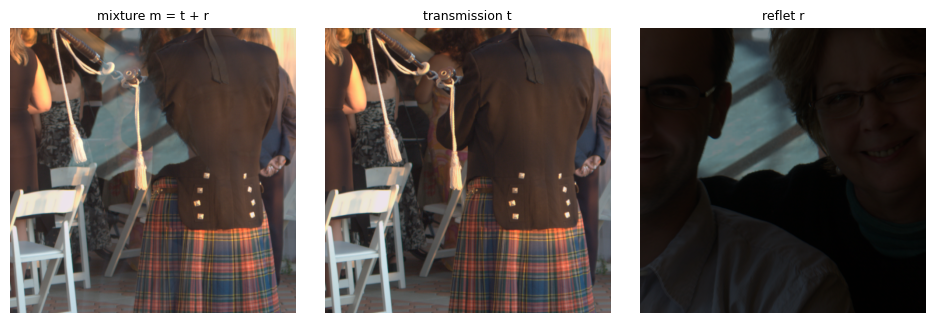

In [134]:
# Démo : on tire des paires réalistes jusqu'à trouver un mélange accepté
ex = None
for i in sat_pool[550:]:
    ia, ib = sample_realistic_pair(rnd)
    cand = simulate_example(pool[1020], pool[i], rng)
    if is_useful(cand):
        ex = cand
        break
assert ex is not None, "aucun mélange accepté — relance la cellule"
print(f"t = {pool[i]['name']} ({pool[i]['loc']}), "
      f"r = {pool[1020]['name']} ({pool[1020]['loc']})")
show_row([ex["m"], ex["t"], ex["r"]],
         ["mixture m = t + r", "transmission t", "reflet r"])
